In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df=pd.read_csv("../data_cleaning/processed_customer_reviews.csv")
df

,Unnamed: 0,order_id,review_id,review_comment_title_en,review_comment_message_en,review_text_combined,sentiment,sentiment_score,primary_topic,topics,classification_reason
0,3,658677c97b385a9be170737859d3511b,e64fb393e7b32834bb789ff8bb30750e,Not Available,I received it well before the stipulated time.,I received it well before the stipulated time.,Positive,0.273,Delivery Speed,Delivery Speed,Positive sentiment; mentions 'before the stipu...
1,4,8e6bfb81e283fa7e4f11123a3fb894f1,f7c4243c7fe1938f181bec41a392bdeb,Not Available,Congratulations Lannister stores I loved shopp...,Congratulations Lannister stores I loved shopp...,Positive,0.960,Positive Experience,Positive Experience,"Positive sentiment; mentions 'congratulations,..."
2,9,b9bf720beb4ab3728760088589c62129,8670d52e15e00043ae7de4c01cc2fe06,I recommend,efficient device. on the website the brand of ...,I recommend - efficient device. on the website...,Positive,0.649,Product Description,"Product Functionality, Product Description, Po...","Positive sentiment; mentions 'another name, pr..."
3,12,9d6f15f95d01e79bd1349cc208361f09,4b49719c8a200003f700d3d986ea1a19,Not Available,But a little slowing down...for the price it's...,But a little slowing down...for the price it's...,Positive,0.593,Price/Value,"Price/Value, Product Quality","Positive sentiment; mentions 'for the price, p..."
4,15,e51478e7e277a83743b6f9991dbfa3fb,3948b09f7c818e2d86c9a546758b2335,highly recommend,"Reliable seller, ok product and delivery on time.","highly recommend - Reliable seller, ok product...",Positive,0.612,Seller Service,"Delivery Speed, Seller Service, Positive Exper...","Positive sentiment; mentions 'reliable seller,..."
...,...,...,...,...,...,...,...,...,...,...,...
42681,99205,d398e9c82363c12527f71801bf0e6100,98fffa80dc9acbde7388bef1600f3b15,Not Available,for this product I received according to the p...,for this product I received according to the p...,Neutral,0.000,Other,Other,Neutral tone detected in review text; no speci...
42682,99208,509b86c65fe4e2ad5b96408cfef9755e,df5fae90e85354241d5d64a8955b2b09,Not Available,Delivered within the time frame. The product a...,Delivered within the time frame. The product a...,Positive,0.795,Positive Experience,Positive Experience,"Positive sentiment; mentions 'perfect, satisfi..."
42683,99215,d5cb12269711bd1eaf7eed8fd32a7c95,a709d176f59bc3af77f4149c96bae357,Not Available,"The product was not sent with an invoice, ther...","The product was not sent with an invoice, ther...",Positive,0.052,Other,Other,Positive tone detected in review text; no spec...
42684,99221,55d4004744368f5571d1f590031933e4,b3de70c89b1510c4cd3d0649fd302472,Not Available,"Excellent backpack, super fast delivery. I hig...","Excellent backpack, super fast delivery. I hig...",Positive,0.893,Positive Experience,Positive Experience,"Positive sentiment; mentions 'excellent, recom..."


In [14]:
df=df[["sentiment","primary_topic"]]

In [16]:
# ------------------------------------------------------------
# 2. SENTIMENT DISTRIBUTION
# ------------------------------------------------------------

sentiment_count = (
    df["sentiment"]
    .value_counts()
)

sentiment_pct = (
    df["sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

sentiment_summary = pd.DataFrame({
    "review_count": sentiment_count,
    "percentage": sentiment_pct
})

print("\n" + "=" * 60)
print("SENTIMENT SUMMARY")
print("=" * 60)

print(sentiment_summary)


SENTIMENT SUMMARY
           review_count  percentage
sentiment                          
Positive          26021       60.96
Neutral           10008       23.45
Negative           6657       15.60


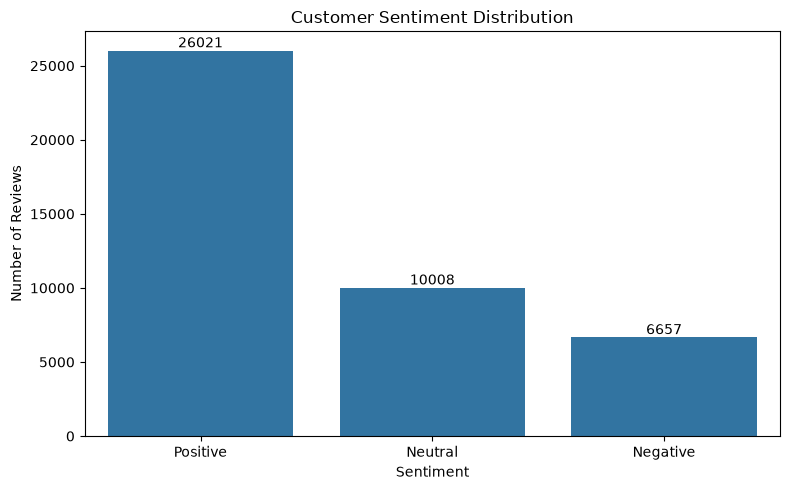

In [21]:
sentiment_order = ["Positive", "Neutral", "Negative"]

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="sentiment",
    order=[
        x for x in sentiment_order
        if x in df["sentiment"].unique()
    ]
)

plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

# Add values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [22]:
topic_count = (
    df["primary_topic"]
    .value_counts()
)

topic_pct = (
    df["primary_topic"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

topic_summary = pd.DataFrame({
    "review_count": topic_count,
    "percentage": topic_pct
})

print("\n" + "=" * 60)
print("TOPIC SUMMARY")
print("=" * 60)

print(topic_summary)



TOPIC SUMMARY
                          review_count  percentage
primary_topic                                     
Positive Experience              14973       35.08
Other                            12594       29.50
Delivery Delay                    3810        8.93
Delivery Speed                    2968        6.95
Product Quality                   2475        5.80
Product Condition/Damage          1229        2.88
Return/Refund                     1015        2.38
Price/Value                        771        1.81
Product Description                683        1.60
Shipping/Logistics                 664        1.56
Packaging                          646        1.51
Seller Service                     298        0.70
Size/Fit                           261        0.61
Product Functionality              253        0.59
Customer Service                    46        0.11


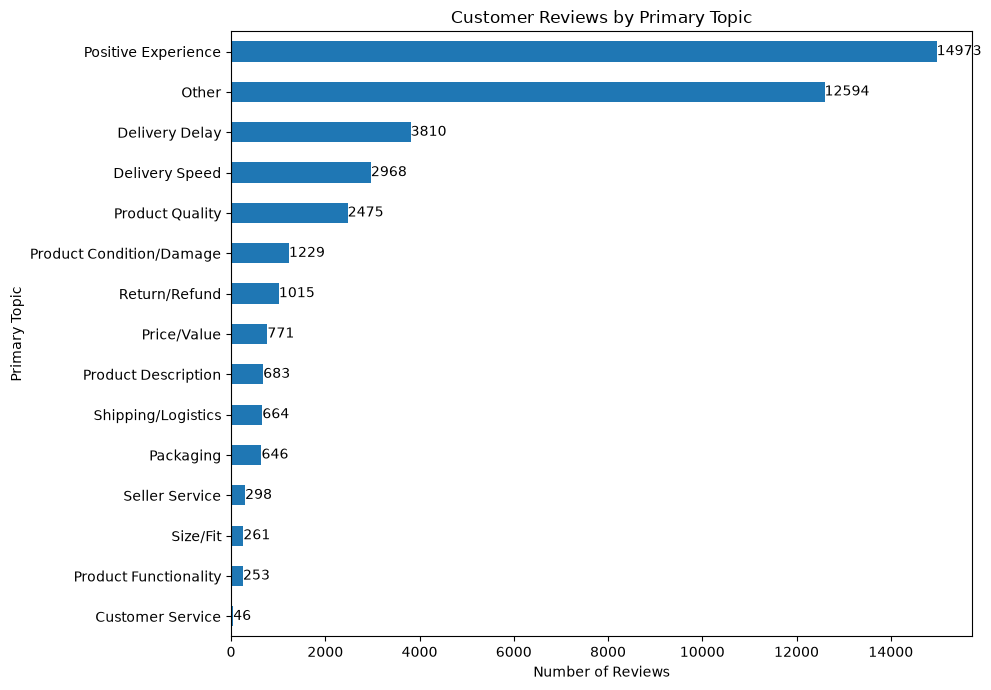

In [23]:
topic_plot = (
    df["primary_topic"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(10, 7))

ax = topic_plot.plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Customer Reviews by Primary Topic")
plt.xlabel("Number of Reviews")
plt.ylabel("Primary Topic")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [24]:
# ------------------------------------------------------------
# 6. TOPIC × SENTIMENT COUNT
# ------------------------------------------------------------

topic_sentiment_count = pd.crosstab(
    df["primary_topic"],
    df["sentiment"]
)

print("\n" + "=" * 60)
print("TOPIC × SENTIMENT COUNT")
print("=" * 60)

print(topic_sentiment_count)


TOPIC × SENTIMENT COUNT
sentiment                 Negative  Neutral  Positive
primary_topic                                        
Customer Service                21        3        22
Delivery Delay                1212     1872       726
Delivery Speed                  85      727      2156
Other                         2241     5992      4361
Packaging                      105       65       476
Positive Experience            350       70     14553
Price/Value                     89       83       599
Product Condition/Damage       885      117       227
Product Description            291      178       214
Product Functionality           83       79        91
Product Quality                426      239      1810
Return/Refund                  459      227       329
Seller Service                  70       47       181
Shipping/Logistics             247      259       158
Size/Fit                        93       50       118


<Figure size 1100x700 with 0 Axes>

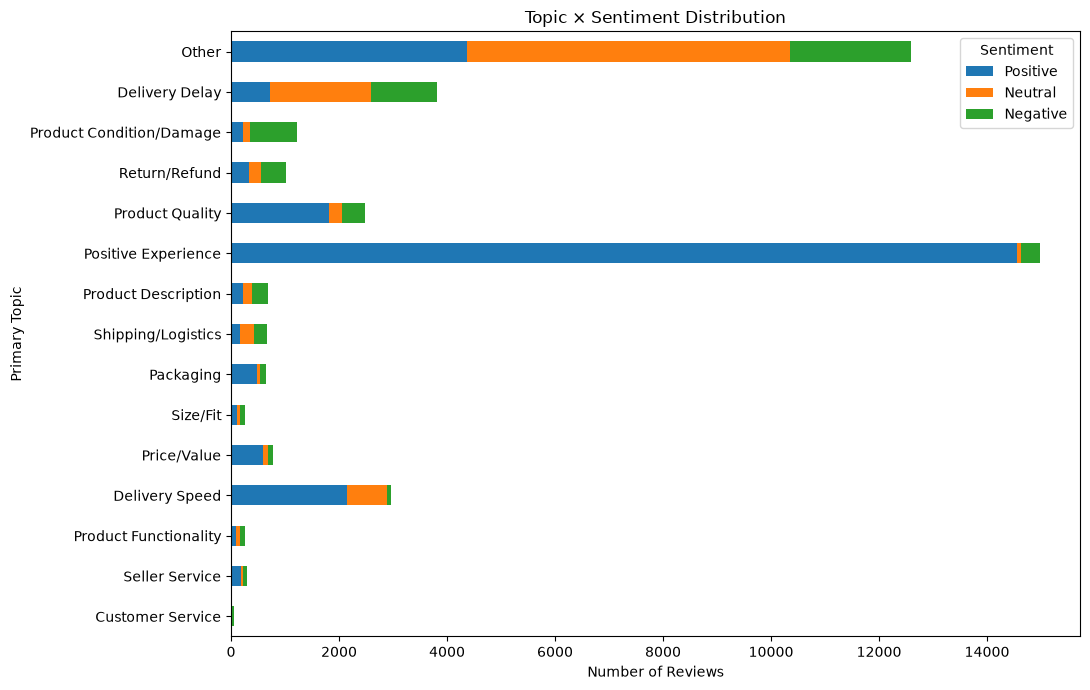

In [25]:
# ------------------------------------------------------------
# 7. TOPIC × SENTIMENT — STACKED BAR
# ------------------------------------------------------------

topic_sentiment_plot = pd.crosstab(
    df["primary_topic"],
    df["sentiment"]
)

# Keep consistent order
available_sentiments = [
    x for x in sentiment_order
    if x in topic_sentiment_plot.columns
]

topic_sentiment_plot = (
    topic_sentiment_plot[available_sentiments]
    .sort_values(
        "Negative",
        ascending=True
    )
    if "Negative" in topic_sentiment_plot.columns
    else topic_sentiment_plot
)

plt.figure(figsize=(11, 7))

topic_sentiment_plot.plot(
    kind="barh",
    stacked=True,
    figsize=(11, 7)
)

plt.title("Topic × Sentiment Distribution")
plt.xlabel("Number of Reviews")
plt.ylabel("Primary Topic")
plt.legend(title="Sentiment")

plt.tight_layout()
plt.show()

In [26]:
# ------------------------------------------------------------
# 8. TOPIC × SENTIMENT PERCENTAGE
# ------------------------------------------------------------

topic_sentiment_pct = pd.crosstab(
    df["primary_topic"],
    df["sentiment"],
    normalize="index"
).mul(100)

print("\n" + "=" * 60)
print("TOPIC × SENTIMENT (%)")
print("=" * 60)

print(topic_sentiment_pct.round(2))


TOPIC × SENTIMENT (%)
sentiment                 Negative  Neutral  Positive
primary_topic                                        
Customer Service             45.65     6.52     47.83
Delivery Delay               31.81    49.13     19.06
Delivery Speed                2.86    24.49     72.64
Other                        17.79    47.58     34.63
Packaging                    16.25    10.06     73.68
Positive Experience           2.34     0.47     97.19
Price/Value                  11.54    10.77     77.69
Product Condition/Damage     72.01     9.52     18.47
Product Description          42.61    26.06     31.33
Product Functionality        32.81    31.23     35.97
Product Quality              17.21     9.66     73.13
Return/Refund                45.22    22.36     32.41
Seller Service               23.49    15.77     60.74
Shipping/Logistics           37.20    39.01     23.80
Size/Fit                     35.63    19.16     45.21


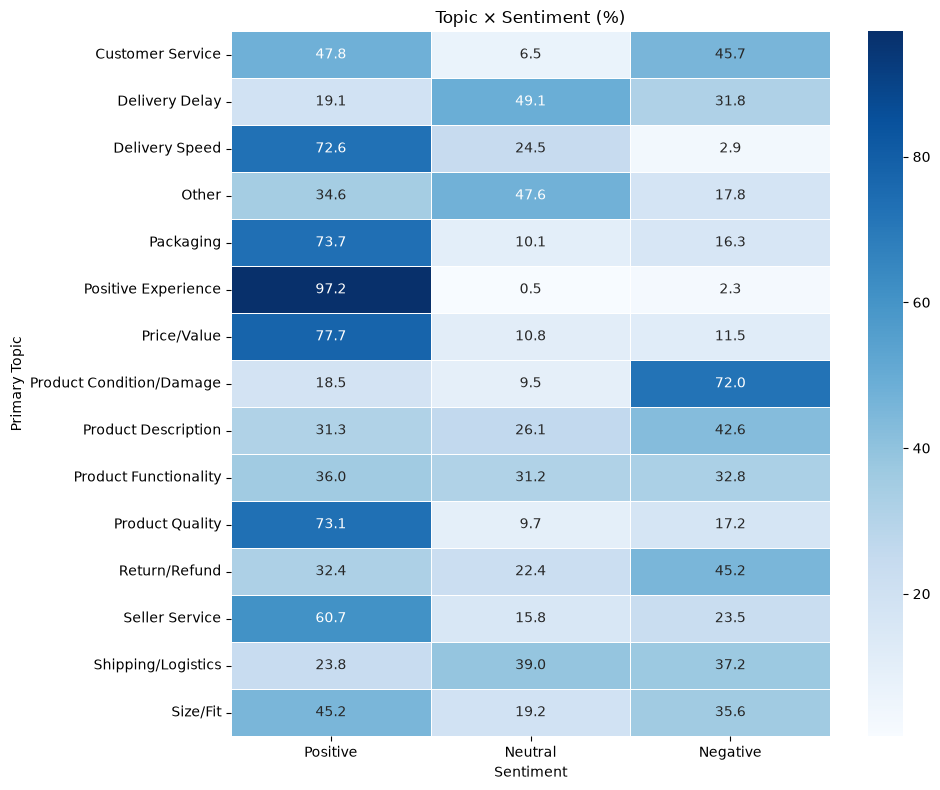

In [29]:
# ------------------------------------------------------------
# 9. TOPIC × SENTIMENT HEATMAP
# ------------------------------------------------------------

heatmap_data = topic_sentiment_pct.copy()

# Order columns
available_sentiments = [
    x for x in sentiment_order
    if x in heatmap_data.columns
]

heatmap_data = heatmap_data[available_sentiments]

plt.figure(figsize=(10, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Blues",   # Reversed: Green → Yellow → Red
    linewidths=0.5
)

plt.title("Topic × Sentiment (%)")
plt.xlabel("Sentiment")
plt.ylabel("Primary Topic")

plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# 10. NEGATIVE SENTIMENT BY TOPIC
# ============================================================

topic_negative = (
    df.groupby("primary_topic")
    .agg(
        total_reviews=("primary_topic", "size"),
        negative_reviews=("sentiment", lambda x:
                          (x == "Negative").sum())
    )
)

topic_negative["negative_rate"] = (
    topic_negative["negative_reviews"]
    / topic_negative["total_reviews"]
    * 100
)

topic_negative = topic_negative.sort_values(
    "negative_rate",
    ascending=False
)

print("\n" + "=" * 60)
print("NEGATIVE SENTIMENT BY TOPIC")
print("=" * 60)

print(topic_negative.round(2))




NEGATIVE SENTIMENT BY TOPIC
                          total_reviews  negative_reviews  negative_rate
primary_topic                                                           
Product Condition/Damage           1229               885          72.01
Customer Service                     46                21          45.65
Return/Refund                      1015               459          45.22
Product Description                 683               291          42.61
Shipping/Logistics                  664               247          37.20
Size/Fit                            261                93          35.63
Product Functionality               253                83          32.81
Delivery Delay                     3810              1212          31.81
Seller Service                      298                70          23.49
Other                             12594              2241          17.79
Product Quality                    2475               426          17.21
Packaging             

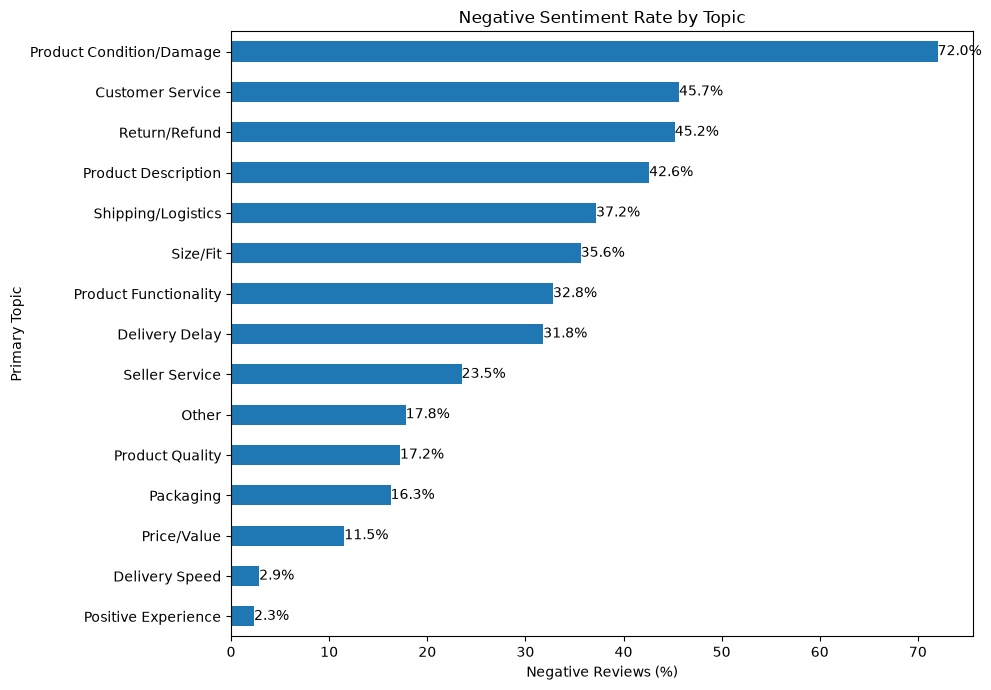

In [31]:
# ------------------------------------------------------------
# 11. NEGATIVE RATE VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

ax = topic_negative["negative_rate"].sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Negative Sentiment Rate by Topic")
plt.xlabel("Negative Reviews (%)")
plt.ylabel("Primary Topic")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.tight_layout()
plt.show()

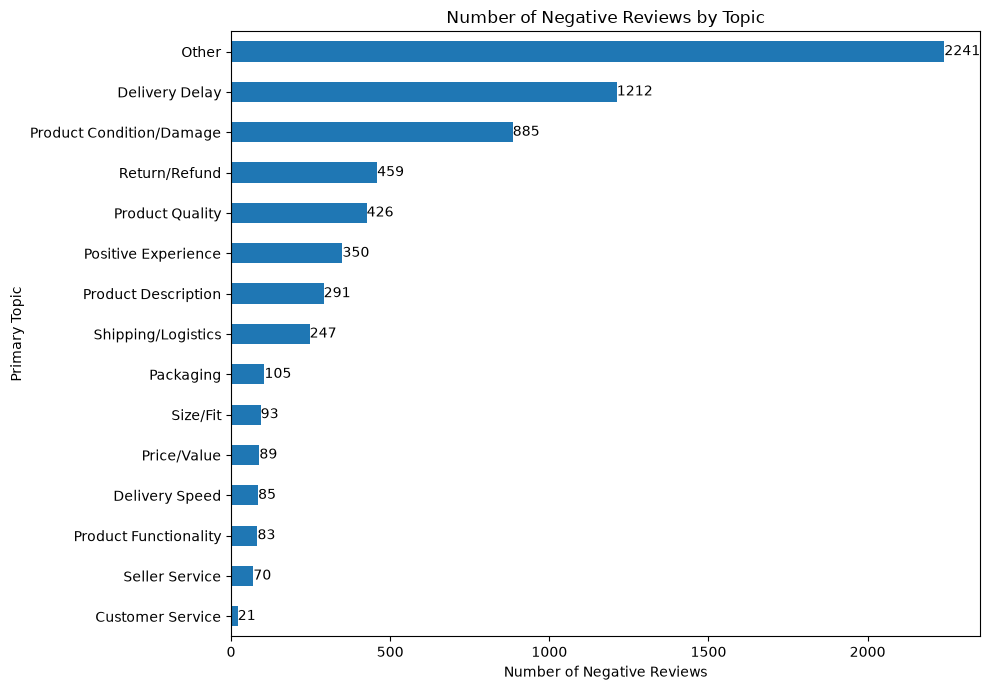


TOPICS WITH MOST POSITIVE REVIEWS
primary_topic
Positive Experience         14553
Other                        4361
Delivery Speed               2156
Product Quality              1810
Delivery Delay                726
Price/Value                   599
Packaging                     476
Return/Refund                 329
Product Condition/Damage      227
Product Description           214
Seller Service                181
Shipping/Logistics            158
Size/Fit                      118
Product Functionality          91
Customer Service               22
Name: count, dtype: int64

TOPICS WITH MOST NEGATIVE REVIEWS
primary_topic
Other                       2241
Delivery Delay              1212
Product Condition/Damage     885
Return/Refund                459
Product Quality              426
Positive Experience          350
Product Description          291
Shipping/Logistics           247
Packaging                    105
Size/Fit                      93
Price/Value                   89
Del

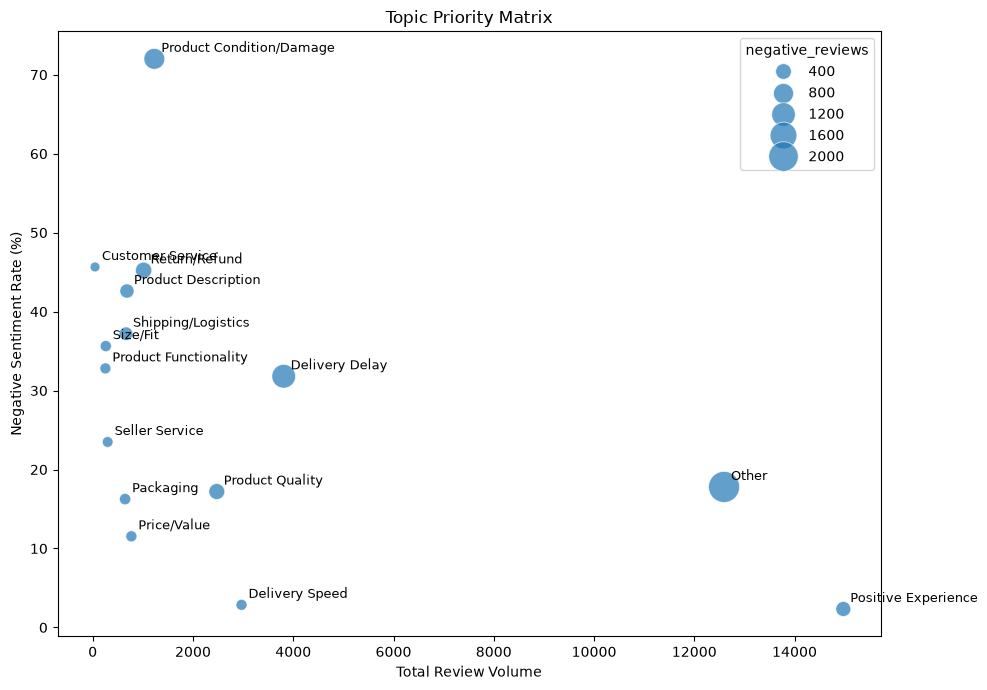


EDA tables successfully exported.


EXECUTIVE SUMMARY

Total Reviews: 42,686
Positive: 26,021 (61.0%)
Neutral: 10,008 (23.4%)
Negative: 6,657 (15.6%)

Most Discussed Topic:
Positive Experience

Topic with Highest Negative Rate:
Product Condition/Damage (72.0%)

Topic with Most Negative Reviews:
Other (2,241 reviews)


In [32]:
# ============================================================
# 12. NEGATIVE REVIEW VOLUME BY TOPIC
# ============================================================

negative_volume = (
    topic_negative
    .sort_values("negative_reviews")
)

plt.figure(figsize=(10, 7))

ax = negative_volume["negative_reviews"].plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Number of Negative Reviews by Topic")
plt.xlabel("Number of Negative Reviews")
plt.ylabel("Primary Topic")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()


# ============================================================
# 13. TOPICS WITH MOST POSITIVE REVIEWS
# ============================================================

positive_by_topic = (
    df[df["sentiment"] == "Positive"]
    ["primary_topic"]
    .value_counts()
)

print("\n" + "=" * 60)
print("TOPICS WITH MOST POSITIVE REVIEWS")
print("=" * 60)

print(positive_by_topic)


# ============================================================
# 14. TOPICS WITH MOST NEGATIVE REVIEWS
# ============================================================

negative_by_topic = (
    df[df["sentiment"] == "Negative"]
    ["primary_topic"]
    .value_counts()
)

print("\n" + "=" * 60)
print("TOPICS WITH MOST NEGATIVE REVIEWS")
print("=" * 60)

print(negative_by_topic)


# ============================================================
# 15. BUSINESS PRIORITY TABLE
# ============================================================

business_priority = (
    df.groupby("primary_topic")
    .agg(
        total_reviews=("primary_topic", "size"),
        positive_reviews=("sentiment",
                          lambda x: (x == "Positive").sum()),
        neutral_reviews=("sentiment",
                         lambda x: (x == "Neutral").sum()),
        negative_reviews=("sentiment",
                          lambda x: (x == "Negative").sum())
    )
)

business_priority["positive_rate"] = (
    business_priority["positive_reviews"]
    / business_priority["total_reviews"]
    * 100
)

business_priority["neutral_rate"] = (
    business_priority["neutral_reviews"]
    / business_priority["total_reviews"]
    * 100
)

business_priority["negative_rate"] = (
    business_priority["negative_reviews"]
    / business_priority["total_reviews"]
    * 100
)

business_priority["negative_impact"] = (
    business_priority["negative_reviews"]
    / len(df)
    * 100
)

business_priority = business_priority.sort_values(
    "negative_reviews",
    ascending=False
)

print("\n" + "=" * 60)
print("BUSINESS PRIORITY ANALYSIS")
print("=" * 60)

print(
    business_priority.round(2)
)


# ============================================================
# 16. HIGH-RISK TOPICS
# ============================================================

# Topics with at least 10 reviews
# and negative rate >= 20%

high_risk_topics = business_priority[
    (business_priority["total_reviews"] >= 10) &
    (business_priority["negative_rate"] >= 20)
].sort_values(
    "negative_rate",
    ascending=False
)

print("\n" + "=" * 60)
print("HIGH-RISK TOPICS")
print("=" * 60)

print(high_risk_topics.round(2))


# ============================================================
# 17. TOPIC PRIORITY MATRIX
# ============================================================

priority_data = business_priority.copy()

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=priority_data,
    x="total_reviews",
    y="negative_rate",
    size="negative_reviews",
    sizes=(50, 500),
    alpha=0.7
)

# Label every topic
for topic, row in priority_data.iterrows():

    plt.annotate(
        topic,
        (
            row["total_reviews"],
            row["negative_rate"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title("Topic Priority Matrix")
plt.xlabel("Total Review Volume")
plt.ylabel("Negative Sentiment Rate (%)")

plt.tight_layout()
plt.show()


# ============================================================
# 18. SAVE EDA TABLES
# ============================================================

sentiment_summary.to_csv(
    "sentiment_summary.csv"
)

topic_summary.to_csv(
    "topic_summary.csv"
)

topic_sentiment_count.to_csv(
    "topic_sentiment_count.csv"
)

topic_sentiment_pct.to_csv(
    "topic_sentiment_percentage.csv"
)

business_priority.to_csv(
    "business_priority.csv"
)

high_risk_topics.to_csv(
    "high_risk_topics.csv"
)

print("\nEDA tables successfully exported.")


# ============================================================
# 19. FINAL EXECUTIVE SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("EXECUTIVE SUMMARY")
print("=" * 70)

print(
    f"\nTotal Reviews: {len(df):,}"
)

print(
    f"Positive: "
    f"{(df['sentiment'] == 'Positive').sum():,} "
    f"({(df['sentiment'] == 'Positive').mean()*100:.1f}%)"
)

print(
    f"Neutral: "
    f"{(df['sentiment'] == 'Neutral').sum():,} "
    f"({(df['sentiment'] == 'Neutral').mean()*100:.1f}%)"
)

print(
    f"Negative: "
    f"{(df['sentiment'] == 'Negative').sum():,} "
    f"({(df['sentiment'] == 'Negative').mean()*100:.1f}%)"
)

print(
    "\nMost Discussed Topic:"
)

print(
    df["primary_topic"].value_counts().idxmax()
)

print(
    "\nTopic with Highest Negative Rate:"
)

print(
    topic_negative["negative_rate"].idxmax(),
    f"({topic_negative['negative_rate'].max():.1f}%)"
)

print(
    "\nTopic with Most Negative Reviews:"
)

print(
    topic_negative["negative_reviews"].idxmax(),
    f"({topic_negative['negative_reviews'].max():,} reviews)"
)
